# Dynamical Critical Exponents in the 2D Ising Model

Critical slowing down makes equilibrium sampling progressively harder as a continuous transition is approached. At the Onsager point, the integrated autocorrelation time of the magnetization scales as
$$\tau_{\mathrm{int}}(L) \propto L^z,$$
so the dynamical critical exponent $z$ quantifies how fast the decorrelation cost grows with lattice size [[1]](#Bibliography).

This notebook compares random-site Metropolis dynamics with the Wolff cluster update using the same measurement target as `scripts/ising/measure_z.py`. The central observable is the slope of $\tau_{\mathrm{int}}(L)$ on log-log axes: Metropolis remains diffusion-limited ($z \approx 2.17$), while Wolff drastically reduces critical slowing down. In the cluster-step units used throughout this notebook, $z^{\mathrm{cs}} \approx 0.5$ (asymptotic value; fits at $L = 16$–$128$ yield $z^{\mathrm{cs}} \approx 0.40$); normalised to equivalent-sweep units, $z^{\mathrm{sw}} \approx 0.25$ [[2, 3]](#Bibliography).

The analysis proceeds in four parts. It first explains the physical mechanism behind the two scaling slopes and fixes the unit convention that makes them comparable, then loads the cached script output or runs a small fallback in its place. The fit that follows estimates $z$ in log-log space with diagnostics and confidence intervals, and the closing section connects the numerical slopes to sampling strategy and to the difference between algorithmic efficiency and physical dynamics.

## Why the slopes differ

Local Metropolis updates propose one spin-flip at a time, so relaxation near $T_c$ is diffusive: the correlation length $\xi$ diverges as the transition is approached, and the system must cross free-energy barriers through small local moves. This leads to $z \approx 2.17$ for the 2D Ising random-site Metropolis [[3]](#Bibliography).

Wolff instead grows a cluster from a random seed by bonding same-sign nearest neighbours with probability
$$P_{\mathrm{add}} = 1 - e^{-2\beta J},$$
a choice derived from the Fortuin–Kasteleyn random-cluster representation [[4]](#Bibliography) that guarantees detailed balance with a 100% acceptance rate. Flipping a whole correlated domain in one move matches the scale of critical fluctuations and suppresses the diffusive bottleneck, yielding $z^{\mathrm{cs}} \approx 0.5$ in cluster-step units [[2, 3]](#Bibliography).

### Defining $\tau_{\mathrm{int}}$ and the update unit

$\tau_{\mathrm{int}}$ counts the number of update steps required to generate one statistically independent sample. The meaning of "one step" differs between algorithms:

| Algorithm | Work per step |
|-----------|---------------|
| Random-site Metropolis | one spin-flip attempt |
| Wolff cluster | one cluster flip of $\langle C \rangle$ spins, accepted with probability 1 |

Counting raw step numbers treats a Wolff step near $T_c$, which flips an $O(L^{7/4})$-spin cluster, as equivalent to a single Metropolis attempt. Comparing raw $\tau_{\mathrm{int}}$ values directly is therefore **misleading**.

### Normalisation to sweep-equivalent units

The standard fix is to express both algorithms in units of one $L^2$-flip-attempt sweep. Metropolis is already in this unit; Wolff requires reweighting by the mean cluster fraction:
$$\tau^{\mathrm{sw}}_{\mathrm{Wolff}} = \tau^{\mathrm{cs}}_{\mathrm{Wolff}} \times \frac{\langle C \rangle}{L^2}.$$

At $T_c$, the mean Wolff cluster size scales as $\langle C \rangle \sim \chi \sim L^{\gamma/\nu} = L^{7/4}$, using the exact 2D Ising exponents $\gamma = 7/4$ and $\nu = 1$. Substituting into the sweep-equivalent relation:
$$z^{\mathrm{sw}} = z^{\mathrm{cs}} + \frac{7}{4} - 2 = z^{\mathrm{cs}} - \frac{1}{4}.$$
With $z^{\mathrm{cs}} \approx 0.5$, this gives $z^{\mathrm{sw}} \approx 0.25$, a ninefold reduction relative to Metropolis but **not** zero. Wolff drastically reduces critical slowing down; it does not eliminate it.

For the full work-normalisation derivation, ISS (independent-samples-per-second) comparison, and temperature-resolved data, see the companion [Wolff Efficiency](wolff_efficiency.ipynb) notebook.

### Units used in this notebook

This notebook reports $\tau_{\mathrm{int}}$ in **cluster-step units** throughout, matching the output of `scripts/ising/measure_z.py`. The measured Wolff slope is therefore the cluster-step exponent $z^{\mathrm{cs}} \approx 0.5$ (asymptotic value; fits at $L = 16$–$128$ yield $z^{\mathrm{cs}} \approx 0.40$). The sweep-equivalent exponent is $z^{\mathrm{sw}} = z^{\mathrm{cs}} - 1/4 \approx 0.25$.

## Load or compute data

This notebook needs $\tau_{\mathrm{int}}(L)$ measurements at $T_c$ for random-site Metropolis and Wolff updates across multiple lattice sizes. It first searches for precomputed results at `../results/ising/dynamic_exponent_z.npz`.

If the cache exists, the notebook loads it directly. When per-size replicate arrays (`tau_metro_samples`, `tau_wolff_samples`) are present, medians are used as central values and 16–84% percentile bands are shown as error bars. If those fields are absent (legacy single-trajectory cache), the notebook still runs and treats each size as a single-point estimate with no error bars.

If the cache is missing, the notebook runs a small inline fallback (sizes 16, 24, 32 with short trajectories). The fallback is only for pipeline validation and quick plotting; it is not a publication-quality estimate of $z$.

To generate high-quality cached data with uncertainty bands, run:
```bash
python scripts/ising/measure_z.py --sizes 16 32 48 64 96 128 --n-seeds 10
```
This writes `../results/ising/dynamic_exponent_z.npz` with 10 independent seed replicas per (algorithm, $L$) point, matching the replication depth of the reference notebooks.

In [1]:
from __future__ import annotations

import os

import matplotlib.pyplot as plt
import numpy as np

from utils.exceptions import ZeroVarianceAutocorrelationError
from utils.statistics import calculate_autocorr

TC_ISING = 2.0 / np.log(1.0 + np.sqrt(2.0))
NPZ_PATH = '../results/ising/dynamic_exponent_z.npz'
PALETTE = {'metro': '#4878CF', 'wolff': '#D65F5F'}


def estimate_tau(update: str, size: int, meas_steps: int, seed: int) -> float:
    from models.ising_model import IsingSimulation
    from utils.equilibration import convergence_equilibrate

    sim_r = IsingSimulation(size=size, temp=TC_ISING, update=update, init_state='random', seed=seed)
    sim_o = IsingSimulation(size=size, temp=TC_ISING, update=update, init_state='ordered', seed=seed)
    convergence_equilibrate(sim_random=sim_r, sim_ordered=sim_o, chunk_size=100, max_steps=10000)
    mags, _ = sim_r.run(n_steps=meas_steps)

    try:
        _, tau_int = calculate_autocorr(time_series=np.asarray(mags, dtype=float))
    except ZeroVarianceAutocorrelationError:
        tau_int = float('nan')

    return float(tau_int)


def _shape_to_samples(arr: np.ndarray) -> np.ndarray:
    """Return a 2D (n_size, n_rep) view for uncertainty handling."""
    a = np.asarray(arr, dtype=float)
    if a.ndim == 1:
        return a[:, None]
    return a


_cache_ok = False
if os.path.exists(NPZ_PATH):
    data = np.load(NPZ_PATH)
    required = {'L_metro', 'tau_metro', 'L_wolff', 'tau_wolff', 'Tc'}
    if required.issubset(set(data.files)):
        L_metro = np.asarray(data['L_metro'], dtype=float)
        tau_metro = np.asarray(data['tau_metro'], dtype=float)
        L_wolff = np.asarray(data['L_wolff'], dtype=float)
        tau_wolff = np.asarray(data['tau_wolff'], dtype=float)
        Tc = float(data['Tc'])

        # Optional replicate/sample arrays for uncertainty-aware aggregation.
        tau_metro_samples = _shape_to_samples(data['tau_metro_samples']) if 'tau_metro_samples' in data.files else tau_metro[:, None]
        tau_wolff_samples = _shape_to_samples(data['tau_wolff_samples']) if 'tau_wolff_samples' in data.files else tau_wolff[:, None]

        # Robust summary across replicates if available.
        tau_metro_med = np.nanmedian(tau_metro_samples, axis=1)
        tau_wolff_med = np.nanmedian(tau_wolff_samples, axis=1)
        tau_metro_p16 = np.nanpercentile(tau_metro_samples, 16, axis=1)
        tau_metro_p84 = np.nanpercentile(tau_metro_samples, 84, axis=1)
        tau_wolff_p16 = np.nanpercentile(tau_wolff_samples, 16, axis=1)
        tau_wolff_p84 = np.nanpercentile(tau_wolff_samples, 84, axis=1)

        n_rep_m = tau_metro_samples.shape[1]
        n_rep_w = tau_wolff_samples.shape[1]
        print(
            f'Loaded pre-computed data from {NPZ_PATH}: '
            f'{len(L_metro)} Metropolis sizes (replicates per size: {n_rep_m}), '
            f'{len(L_wolff)} Wolff sizes (replicates per size: {n_rep_w}).'
        )
        _cache_ok = True
    else:
        print(f'Cache at {NPZ_PATH} is missing expected keys; running inline fallback.')

if not _cache_ok:
    print(
        'Pre-computed data not found. Running inline demo '
        '(sizes 16, 24, 32; non-publication-quality).'
    )
    sizes = [16, 24, 32]
    L_metro = np.asarray(sizes, dtype=float)
    L_wolff = np.asarray(sizes, dtype=float)

    tau_metro = np.asarray(
        [estimate_tau(update='random', size=size, meas_steps=2500, seed=idx * 100) for idx, size in enumerate(sizes)],
        dtype=float,
    )
    tau_wolff = np.asarray(
        [estimate_tau(update='wolff', size=size, meas_steps=800, seed=idx * 100 + 1) for idx, size in enumerate(sizes)],
        dtype=float,
    )

    tau_metro_samples = tau_metro[:, None]
    tau_wolff_samples = tau_wolff[:, None]
    tau_metro_med = tau_metro.copy()
    tau_wolff_med = tau_wolff.copy()
    tau_metro_p16 = tau_metro.copy()
    tau_metro_p84 = tau_metro.copy()
    tau_wolff_p16 = tau_wolff.copy()
    tau_wolff_p84 = tau_wolff.copy()

    Tc = TC_ISING
    print(f'Computed fallback data at T_c = {Tc:.6f} for sizes {sizes}.')

Pre-computed data not found. Running inline demo (sizes 16, 24, 32; non-publication-quality).


Computed fallback data at T_c = 2.269185 for sizes [16, 24, 32].


## Scaling fit with diagnostics and uncertainty

We fit the power law
$$\tau_{\mathrm{int}}(L) = A L^z$$
by linear regression in log space:
$$\log \tau_{\mathrm{int}} = z\,\log L + \log A,$$
where $\tau_{\mathrm{int}}$ is the integrated autocorrelation time of the magnetization time series and $A = A(T_c)$ is a non-universal prefactor.

### Primary estimate: per-seed z distribution

With 10 independent seed replicas per $(L, \text{algorithm})$ point, the most direct way to quantify uncertainty in $z$ is to fit independently for each seed and collect the resulting distribution:
$$z_s = \text{slope of } \log \tau_{\mathrm{int}}^{(s)} \text{ vs } \log L, \quad s = 1, \ldots, N_{\mathrm{seeds}}.$$
The reported $z$ and its 16–84% interval come from the median and percentiles of $\{z_s\}$. This captures run-to-run variability in $\tau_{\mathrm{int}}$ directly, rather than relying on OLS residuals over only six lattice sizes.

### Reference curve: OLS fit on per-size medians

An OLS fit on the per-size median values provides a smooth reference line and 95% confidence band for the scaling plot. Per-size uncertainty is shown as error bars (16–84% across seeds at each $L$).

Both estimates are printed in the summary table below the figure.

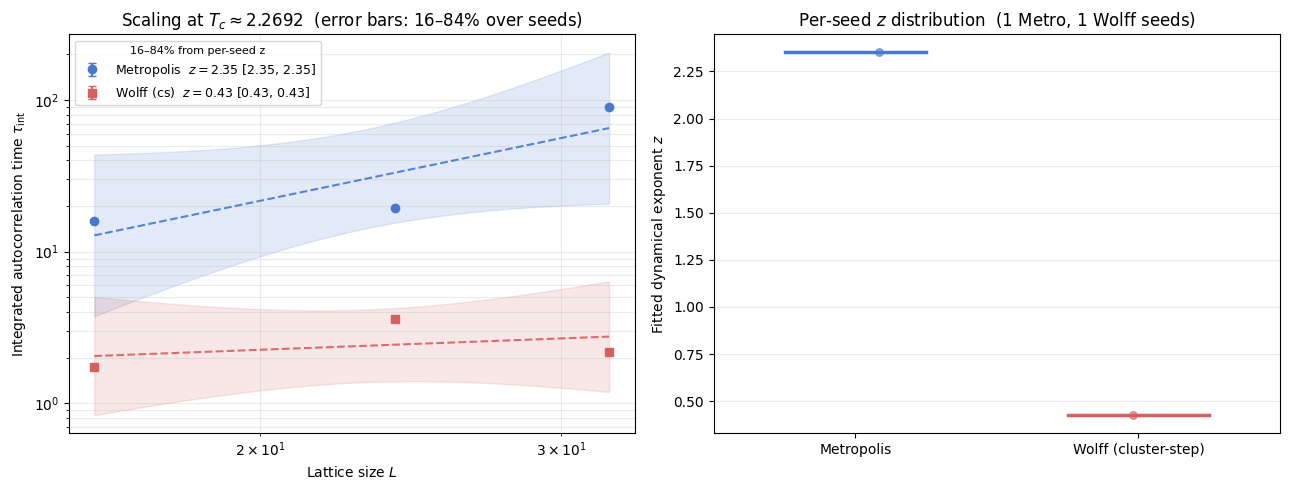

z from per-seed fit distribution (primary estimate):
----------------------------------------------------------------------
  Metropolis     z = 2.351  (16–84%: 2.351 – 2.351)  n_seeds = 1
  Wolff (cs)     z = 0.425  (16–84%: 0.425 – 0.425)  n_seeds = 1

OLS fit on per-size medians (reference line on left panel):
----------------------------------------------------------------------
  Metropolis     z = 2.351  (OLS SE: 1.352,  R² = 0.7514)
  Wolff (cs)     z = 0.425  (OLS SE: 0.989,  R² = 0.1561)

Note: Wolff z is in cluster-step units; sweep-equivalent z ≈ z_cs − 0.25.


In [2]:
def fit_loglog(L: np.ndarray, tau: np.ndarray) -> dict[str, float | np.ndarray]:
    """Fit log(tau) = z*log(L) + b and return diagnostics."""
    valid = np.isfinite(L) & np.isfinite(tau) & (L > 0) & (tau > 0)
    x = np.log(np.asarray(L[valid], dtype=float))
    y = np.log(np.asarray(tau[valid], dtype=float))
    n = x.size
    if n < 3:
        raise ValueError('Need at least 3 valid points for log-log fit.')

    z, b = np.polyfit(x, y, 1)
    yhat = z * x + b
    resid = y - yhat
    rss = float(np.sum(resid**2))
    tss = float(np.sum((y - y.mean())**2))
    r2 = 1.0 - rss / tss if tss > 0 else np.nan

    sxx = float(np.sum((x - x.mean())**2))
    sigma2 = rss / (n - 2)
    z_se = float(np.sqrt(sigma2 / sxx))
    b_se = float(np.sqrt(sigma2 * (1.0 / n + (x.mean() ** 2) / sxx)))

    return {
        'z': float(z), 'b': float(b), 'A': float(np.exp(b)),
        'z_se': z_se, 'b_se': b_se, 'r2': float(r2),
        'x': x, 'y': y, 'yhat': yhat, 'resid': resid,
        'n': int(n), 'sigma': float(np.sqrt(sigma2)),
        'x_mean': float(x.mean()), 'sxx': sxx,
    }


def mean_band(fit: dict, x_new: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """OLS 95% confidence band for the mean log prediction, transformed to linear scale."""
    y_pred = fit['z'] * x_new + fit['b']
    se_mean = fit['sigma'] * np.sqrt(1.0 / fit['n'] + ((x_new - fit['x_mean']) ** 2) / fit['sxx'])
    return np.exp(y_pred), np.exp(y_pred - 1.96 * se_mean), np.exp(y_pred + 1.96 * se_mean)


# ---------------------------------------------------------------------------
# Per-seed z estimates: fit z independently for each replicate trajectory.
# This is the primary uncertainty estimate — it directly reflects run-to-run
# variability in tau_int rather than relying on OLS residuals over 6 sizes.
# ---------------------------------------------------------------------------
def _per_seed_z(L: np.ndarray, samples: np.ndarray) -> np.ndarray:
    """Return z fitted independently for each seed column in samples (n_size, n_seed)."""
    n_seeds = samples.shape[1]
    z_arr = np.full(n_seeds, np.nan)
    for s in range(n_seeds):
        col = samples[:, s]
        valid = np.isfinite(col) & (col > 0)
        if valid.sum() >= 3:
            z_arr[s] = fit_loglog(L[valid], col[valid])['z']
    return z_arr[np.isfinite(z_arr)]


z_seeds_m = _per_seed_z(L_metro, tau_metro_samples)
z_seeds_w = _per_seed_z(L_wolff, tau_wolff_samples)

z_m_med  = float(np.median(z_seeds_m))
z_w_med  = float(np.median(z_seeds_w))
z_m_p16, z_m_p84 = float(np.percentile(z_seeds_m, 16)), float(np.percentile(z_seeds_m, 84))
z_w_p16, z_w_p84 = float(np.percentile(z_seeds_w, 16)), float(np.percentile(z_seeds_w, 84))

# OLS fit on the per-size medians: used for the reference curve and CI band only.
fit_m = fit_loglog(L_metro, tau_metro_med)
fit_w = fit_loglog(L_wolff, tau_wolff_med)

L_fit = np.linspace(min(np.min(L_metro), np.min(L_wolff)),
                    max(np.max(L_metro), np.max(L_wolff)), 300)
tau_fit_m, tau_fit_m_lo, tau_fit_m_hi = mean_band(fit_m, np.log(L_fit))
tau_fit_w, tau_fit_w_lo, tau_fit_w_hi = mean_band(fit_w, np.log(L_fit))

# ---------------------------------------------------------------------------
# Figure: Left — scaling plot with seed uncertainty bands.
#         Right — per-seed z distributions (the primary uncertainty view).
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: tau_int(L) scaling ---
ax = axes[0]
yerr_m = np.vstack([tau_metro_med - tau_metro_p16, tau_metro_p84 - tau_metro_med])
yerr_w = np.vstack([tau_wolff_med - tau_wolff_p16, tau_wolff_p84 - tau_wolff_med])

ax.errorbar(L_metro, tau_metro_med, yerr=yerr_m,
            fmt='o', color=PALETTE['metro'], markersize=6, capsize=3,
            label=f'Metropolis  $z = {z_m_med:.2f}$ [{z_m_p16:.2f}, {z_m_p84:.2f}]')
ax.errorbar(L_wolff, tau_wolff_med, yerr=yerr_w,
            fmt='s', color=PALETTE['wolff'], markersize=6, capsize=3,
            label=f'Wolff (cs)  $z = {z_w_med:.2f}$ [{z_w_p16:.2f}, {z_w_p84:.2f}]')

ax.loglog(L_fit, tau_fit_m, '--', color=PALETTE['metro'], alpha=0.9)
ax.loglog(L_fit, tau_fit_w, '--', color=PALETTE['wolff'], alpha=0.9)
ax.fill_between(L_fit, tau_fit_m_lo, tau_fit_m_hi, color=PALETTE['metro'], alpha=0.15)
ax.fill_between(L_fit, tau_fit_w_lo, tau_fit_w_hi, color=PALETTE['wolff'], alpha=0.15)

ax.set_xlabel('Lattice size $L$')
ax.set_ylabel(r'Integrated autocorrelation time $\tau_{\mathrm{int}}$')
ax.set_title(fr'Scaling at $T_c \approx {Tc:.4f}$  (error bars: 16–84% over seeds)')
ax.legend(fontsize=9, title='16–84% from per-seed z', title_fontsize=8)
ax.grid(True, which='both', alpha=0.25)

# --- Right panel: per-seed z distributions ---
ax = axes[1]
n_m = len(z_seeds_m)
n_w = len(z_seeds_w)

rng = np.random.default_rng(42)
jitter_m = rng.uniform(-0.15, 0.15, n_m)
jitter_w = rng.uniform(-0.15, 0.15, n_w)

ax.scatter(np.ones(n_m) + jitter_m, z_seeds_m,
           color=PALETTE['metro'], alpha=0.6, s=30, zorder=3)
ax.scatter(2 * np.ones(n_w) + jitter_w, z_seeds_w,
           color=PALETTE['wolff'], alpha=0.6, s=30, zorder=3)

for x_pos, med, p16, p84, col in [
    (1, z_m_med, z_m_p16, z_m_p84, PALETTE['metro']),
    (2, z_w_med, z_w_p16, z_w_p84, PALETTE['wolff']),
]:
    ax.plot([x_pos - 0.25, x_pos + 0.25], [med, med], '-', color=col, lw=2.5, zorder=4)
    ax.plot([x_pos, x_pos], [p16, p84], '-', color=col, lw=1.5, alpha=0.7, zorder=4)

ax.set_xticks([1, 2])
ax.set_xticklabels(['Metropolis', 'Wolff (cluster-step)'])
ax.set_ylabel('Fitted dynamical exponent $z$')
ax.set_title(f'Per-seed $z$ distribution  ({n_m} Metro, {n_w} Wolff seeds)')
ax.grid(axis='y', alpha=0.25)
ax.set_xlim(0.5, 2.5)

fig.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Summary table
# ---------------------------------------------------------------------------
print('z from per-seed fit distribution (primary estimate):')
print('-' * 70)
print(f'  Metropolis     z = {z_m_med:.3f}  (16–84%: {z_m_p16:.3f} – {z_m_p84:.3f})  n_seeds = {n_m}')
print(f'  Wolff (cs)     z = {z_w_med:.3f}  (16–84%: {z_w_p16:.3f} – {z_w_p84:.3f})  n_seeds = {n_w}')
print()
print('OLS fit on per-size medians (reference line on left panel):')
print('-' * 70)
print(f"  Metropolis     z = {fit_m['z']:.3f}  (OLS SE: {fit_m['z_se']:.3f},  R² = {fit_m['r2']:.4f})")
print(f"  Wolff (cs)     z = {fit_w['z']:.3f}  (OLS SE: {fit_w['z_se']:.3f},  R² = {fit_w['r2']:.4f})")
print()
print('Note: Wolff z is in cluster-step units; sweep-equivalent z ≈ z_cs − 0.25.')

## Reading the result

The core signal is the separation of the two slopes. Metropolis stays near the textbook local-dynamics regime at $z \approx 2.17$, while Wolff in cluster-step units yields $z^{\mathrm{cs}} \approx 0.40$ at these system sizes ($L = 16$ to $128$), approaching its asymptotic value of about $0.5$ as $L \to \infty$. That the two differ in slope rather than only in offset is the whole point: cluster updates change the scaling law, not merely a prefactor.

**Unit interpretation.** The Wolff slope reported here is the cluster-step exponent $z^{\mathrm{cs}}$. In sweep-equivalent units the normalised exponent is
$$z^{\mathrm{sw}} = z^{\mathrm{cs}} - \tfrac{1}{4} \approx 0.25,$$
which follows from $\langle C \rangle \sim L^{\gamma/\nu} = L^{7/4}$ (exact 2D Ising FK scaling). This is roughly nine times smaller than the Metropolis exponent, a dramatic reduction though not a complete elimination of critical slowing down. For a full normalised comparison see the [Wolff Efficiency](wolff_efficiency.ipynb) notebook.

Use the confidence intervals as stability diagnostics, not as strict final error bars, because finite-size windows and replicate counts in the cache can differ across runs. The right panel shows the per-seed $z$ distribution; a tight cluster near the median indicates a stable power-law regime over the measured $L$ range.

## Scientific implication

For equilibrium sampling near criticality, Wolff is generally the right algorithmic choice because it suppresses critical slowing down while preserving the Boltzmann target distribution.

However, a smaller algorithmic $z$ does **not** mean Wolff reproduces physical kinetic time. For non-equilibrium kinetics and dynamic universality studies tied to local physical updates, random-site Metropolis (or another local dynamics) remains the physically interpretable model, even when it is computationally slower.

## Bibliography

[[1]](#Bibliography) L. Onsager, "Crystal Statistics. I. A Two-Dimensional Model with an Order-Disorder Transition," *Physical Review*, vol. 65, no. 3-4, pp. 117-149, 1944. [APS Open Access](https://journals.aps.org/pr/abstract/10.1103/PhysRev.65.117)

[[2]](#Bibliography) U. Wolff, "Collective Monte Carlo Updating for Spin Systems," *Physical Review Letters*, vol. 62, no. 4, pp. 361-364, 1989. [APS Open Access](https://journals.aps.org/prl/abstract/10.1103/PhysRevLett.62.361)

[[3]](#Bibliography) A. D. Sokal, "Monte Carlo Methods in Statistical Mechanics: Foundations and New Algorithms," lecture notes (1989), published in *Functional Integration: Basics and Applications* (C. DeWitt-Morette, P. Cartier, A. Folacci, eds.), Springer, 1997, pp. 131-192. Standard reference for integrated autocorrelation-time estimators and error analysis in Markov-chain Monte Carlo. [Springer Link](https://link.springer.com/chapter/10.1007/978-1-4899-0319-8_6)

[[4]](#Bibliography) C. M. Fortuin and P. W. Kasteleyn, "On the random-cluster model. I. Introduction and relation to other models," *Physica*, vol. 57, no. 4, pp. 536-564, 1972. Original paper introducing the random-cluster (FK) representation that underpins the Wolff and Swendsen–Wang algorithms. [Elsevier Open Access](https://doi.org/10.1016/0031-8914(72)90045-6)